# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Daniel Shipton, Samuel Fitzgerald, Nifemi Omoshuli]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  



## 1. Problem Definition & Strategic Scoping 

### 1.1 Strategic Scoping 

Walmart operates in a highly competitive, low-margin market where efficiency and quick responses to demand are crucial for profit. Accurate sales forecasting is essential for managing inventory, staffing, supply chains, promotions, and finances. 

Inaccurate forecasts can cause major problems. Overestimating demand leads to overstocking, higher costs, and wasted products. Underestimating demand results in stockouts, lost sales, and unhappy customers. Even small forecasting errors can add up to significant financial losses across departments and regions. 

Retail demand is shaped by several factors: 

1) Seasonal changes (like holidays) 

2) Unemployment and inflation 

3) External costs (such as fuel prices, which can reduce customer spending) 

4) Local store knowledge 

A strong business intelligence system can identify these demand drivers, deliver reliable forecasts, and give the company a competitive edge. 

### 1.2 Business Problem Statement 

This project explores how historical weekly sales data from Walmart stores can be used to accurately forecast future sales and identify the main factors driving sales variability. These insights will support data-driven operational planning. 

The problem is divided into two parts: 

1) Predictive: Generating forward-looking sales forecasts. 

2) Diagnostic: Understanding what drives sales variation. 

By combining forecasting with explanatory analysis, this project moves beyond technical modeling to deliver actionable business intelligence—directly addressing the goal of applying data mining to real-world business problems. 

## 2. Technical Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("Walmart.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)


weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)

weekly_total['Time_Index'] = range(len(weekly_total))

# Drop NA from lag/rolling
weekly_total = weekly_total.dropna().reset_index(drop=True)

# Features
features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]

X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

# Train/test split
split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Setup complete")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Setup complete
Training samples: 104
Testing samples: 27


In [2]:
# =========================
# MASTER MODEL CELL — RUN FIRST
# =========================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# -------------------------
# Random Forest
# -------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -------------------------
# Gradient Boosting
# -------------------------
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# -------------------------
# Decision Tree (baseline non-linear)
# -------------------------
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# -------------------------
# MLP Neural Network (scaled X & y)
# -------------------------
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# -------------------------
# SVR (scaled X & y)
# -------------------------
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1000, gamma=0.01))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

print("All models trained successfully.")

All models trained successfully.


In [3]:
from sklearn.linear_model import LinearRegression, Ridge  

# -------------------------
# Linear Regression
# -------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# -------------------------
# Ridge Regression
# -------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

In [4]:
# =========================
# MASTER PLOT FUNCTION — RUN ONCE
# =========================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_forecast(y_true, y_pred, model_name):
    plt.figure(figsize=(12,6))

    plt.plot(y_true.values, label="Actual Weekly Sales", linewidth=3)
    plt.plot(y_pred, label=model_name)

    plt.title(f"{model_name} — Actual vs Predicted Weekly Sales")
    plt.xlabel("Forecast Horizon (Weeks)")
    plt.ylabel("Weekly Sales ($ Millions)")

    # Format y-axis to millions
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
    )

    plt.legend()
    plt.show()

In [5]:
# =========================
# MASTER METRICS CELL for metrics comparison table 
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----- Random Forest -----
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# ----- Gradient Boosting -----
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

# ----- MLP -----
mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp   = r2_score(y_test, y_pred_mlp)

# ----- SVR -----
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 3. Data Quality Assessment

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing

### 3.1 Data quality check

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [8]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [9]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


### 3.2 Summary of Data Quality

The dataset includes 6,435 observations across 8 variables, all of which are complete with no missing values. Numeric features are correctly typed, though the Date column, stored as a string, will need to be converted to datetime during preprocessing. 

Weekly_Sales varies widely, reflecting differences between stores and over time. External factors like Temperature, Fuel_Price, CPI, and Unemployment also change and could impact sales. 

Overall, the dataset is clean and ready for analysis, needing only minimal preprocessing. 

## 4. Feature Engineering & Preprocessing

These features enable the identification of seasonal trends and temporal patterns in weekly sales, such as fluctuations across months and peak periods during holidays. Incorporating these variables enhances the effectiveness of both exploratory analysis and predictive modelling by allowing models to account for time-dependent behaviour.

### 4.1 Time-Based Features

The Date variable was processed earlier, so the dataset already includes key time-based features like Year, Month, Week, and Day. These features help identify seasonal trends and patterns. 


In [10]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


The dataset now includes additional time-based variables derived from the original date information, confirming that preprocessing has been successfully applied.

## 5. Data Aggregation

To simplify analysis and reduce store-level noise, the dataset is aggregated at a weekly level. This makes overall sales trends easier to observe and provides a more suitable structure for time-series analysis and forecasting.

### 5.1 Weekly Aggregation

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


To reduce store-level noise and simplify analysis, the data is aggregated weekly. This makes sales trends clearer and better supports time-series forecasting. 

### 5.2 Aggregation Rationale

Data was aggregated by Date to create a weekly time series of total sales. Weekly_Sales was summed for total revenue, while Temperature, Fuel_Price, CPI, and Unemployment were averaged to represent weekly external conditions. 

Holiday_Flag used the maximum value to mark any week with a holiday. This approach further simplifies the dataset and highlights sales trends for easier analysis and forecasting. 

## 6. Exploratory Data Analysis (EDA)

#### 6.1 External Variables

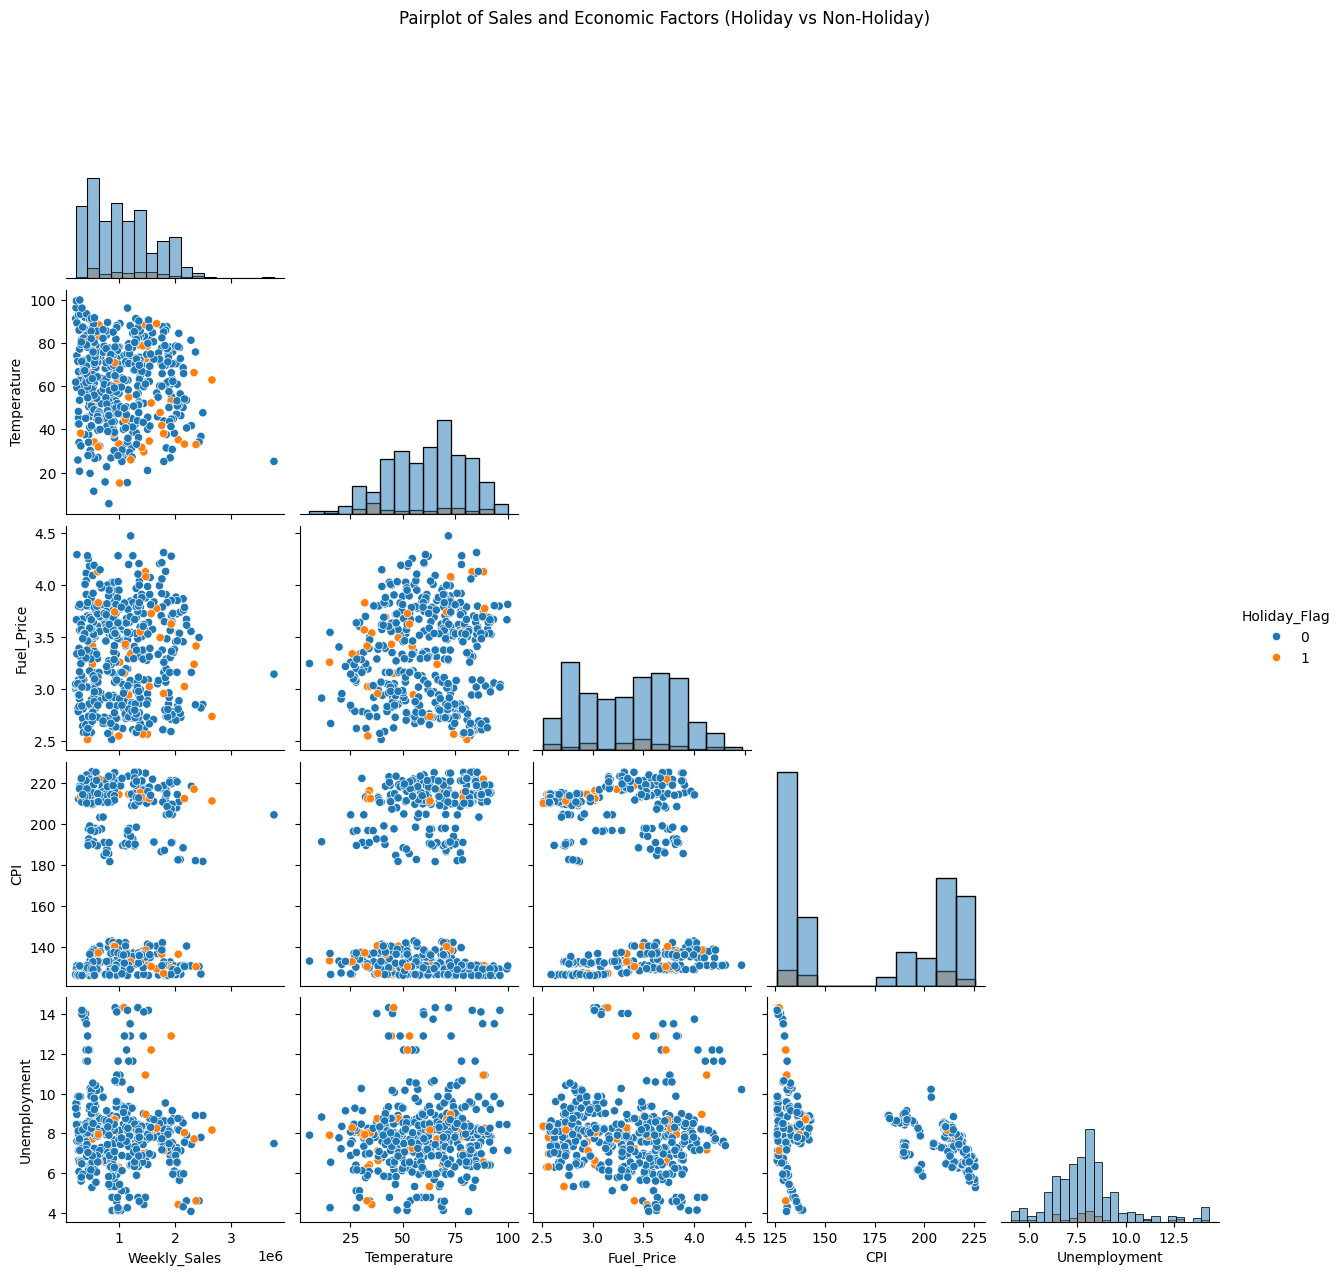

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

Pairplots show that weekly sales have weak, non-linear relationships with temperature, fuel price, CPI, and unemployment. No single variable strongly predicts sales; instead, sales are shaped by a mix of factors. This complexity supports using advanced models like Random Forest to capture these patterns. 

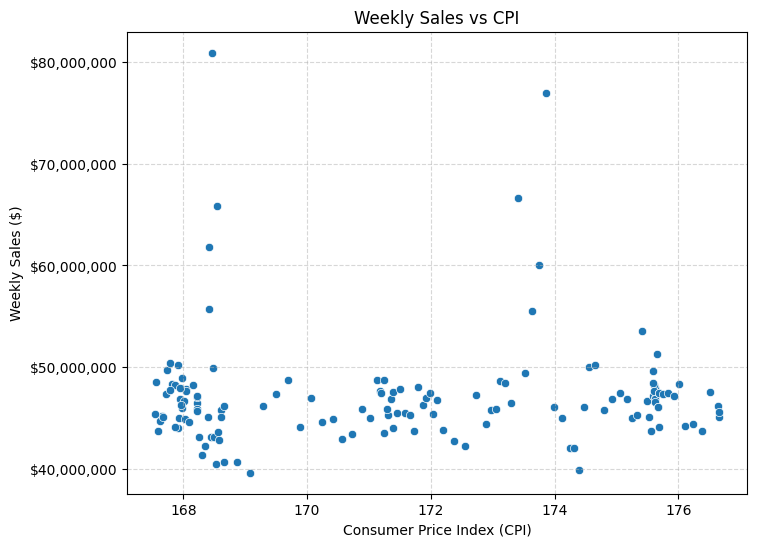

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="CPI", y="Weekly_Sales")

# Format Y-axis as currency ($)
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales ($)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Scatter plots show a weak, non-linear relationship between Weekly Sales and CPI, with clusters that may reflect different economic periods. CPI may influence sales, but it isn’t a strong standalone predictor and likely interacts with other variables. 

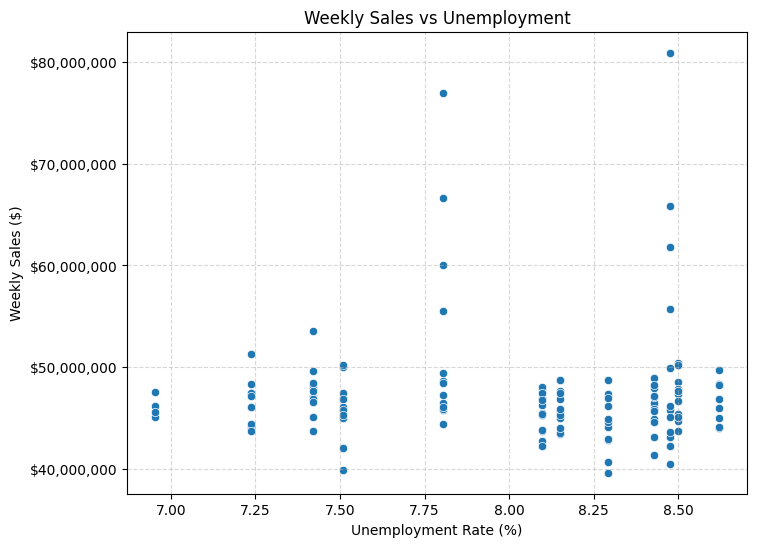

In [14]:
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Unemployment", y="Weekly_Sales")

# Format Y-axis as currency ($)
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Weekly Sales ($)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

There is a weak, slightly negative link between unemployment and sales. Unemployment alone does not predict sales well and likely works with other variables to influence outcomes. 

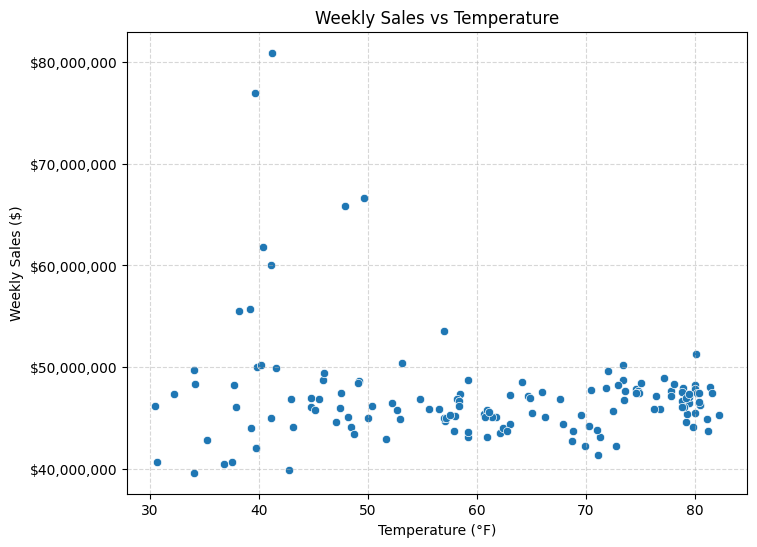

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Temperature", y="Weekly_Sales")

# Format Y-axis as currency ($)
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature (°F)")  # or °C depending on dataset
plt.ylabel("Weekly Sales ($)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Weekly sales and temperature show no clear relationship, so temperature is not a strong predictor in this model. 

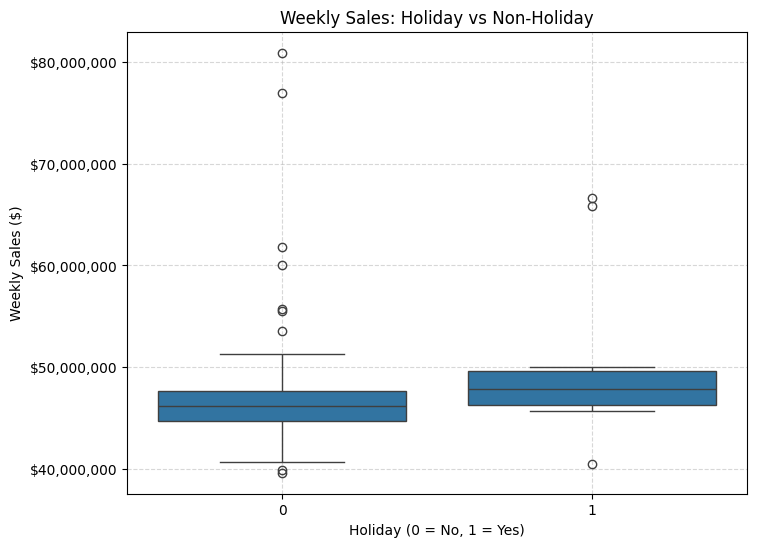

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))

sns.boxplot(data=weekly_total, x="Holiday_Flag", y="Weekly_Sales")

# Format Y-axis as currency ($)
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales ($)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Weekly sales are higher and more variable during holidays than non-holiday weeks. 

Still, holidays aren’t the only reason for high sales—seasonal and time-based factors also matter. 

Holiday_Flag is helpful but should be used with other features in forecasting. 

#### 6.2 Sales Trend over time 

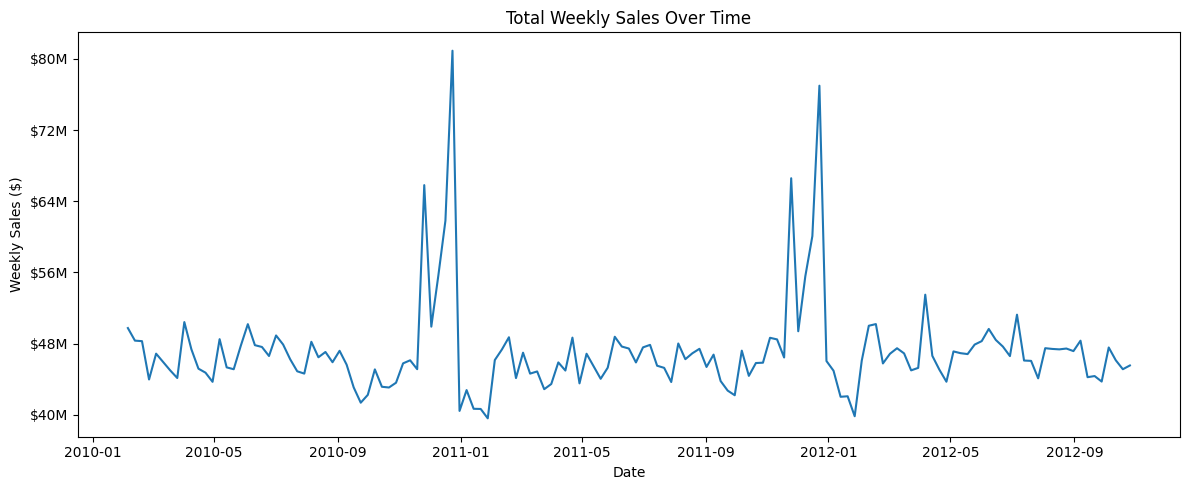

In [17]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")

ax = plt.gca()

# Format to $ millions
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)

# OPTIONAL: cleaner tick spacing (THIS is the bit you asked about)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

Time series plots reveal sales peaks at year-end, showing strong seasonal demand patterns. 

Sales rise from October to December, then drop sharply in January, which matches typical holiday and post-holiday retail trends. 

#### 6.3 Rolling Average Trend

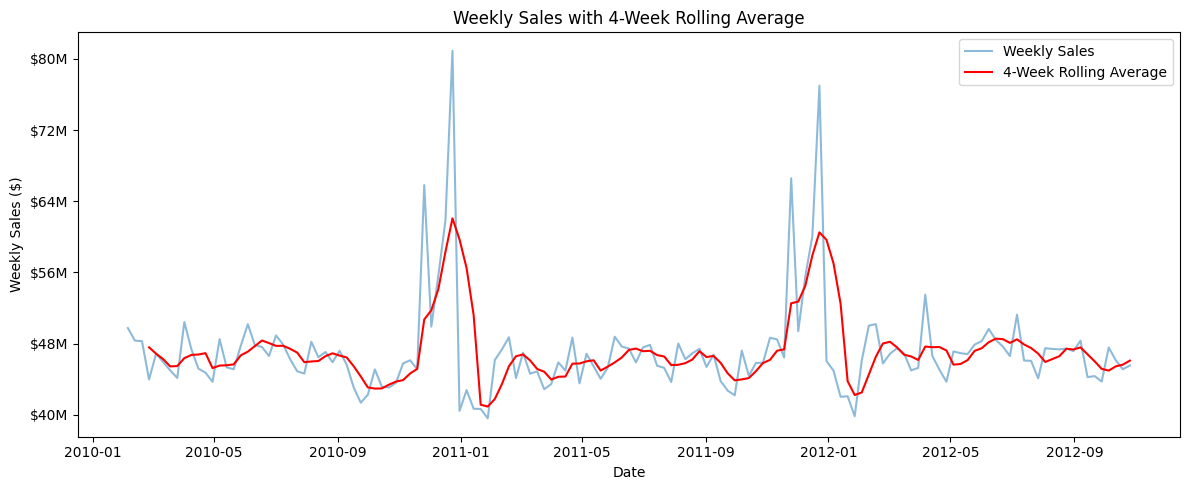

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')

plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")

plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

A 4-week rolling average smooths out short-term shifts and confirms stable sales with clear seasonal peaks and a January drop. 

#### 6.4 Monthly seasonality

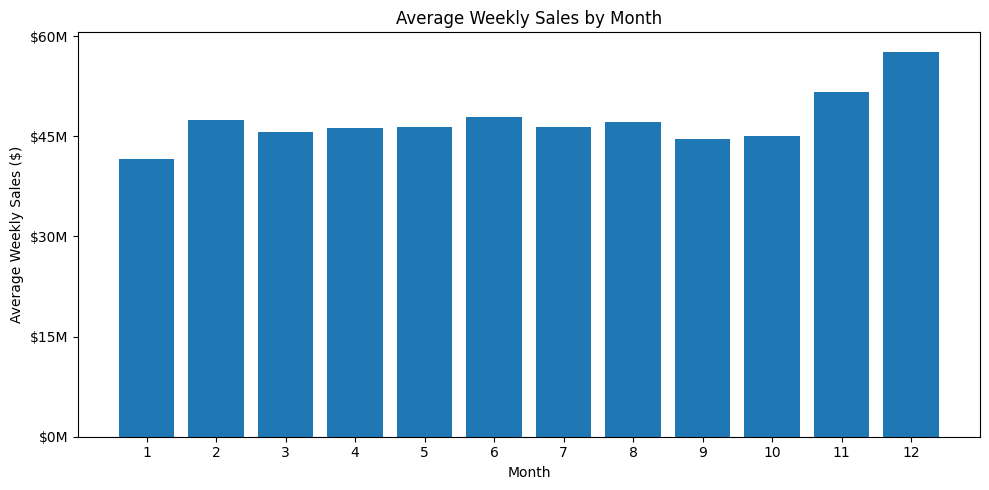

In [19]:
import matplotlib.ticker as ticker

# Create Month column from Date
weekly_total['Month'] = weekly_total['Date'].dt.month

# Calculate average weekly sales by month
monthly_avg = (
    weekly_total
    .groupby('Month', as_index=False)['Weekly_Sales']
    .mean()
)

# Plot monthly seasonality
plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales ($)")
plt.xticks(range(1,13))

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

Monthly data shows clear seasonal sales patterns: a December peak and January decline, likely tied to holiday shopping. 

#### 6.5 Correlation Matrix 

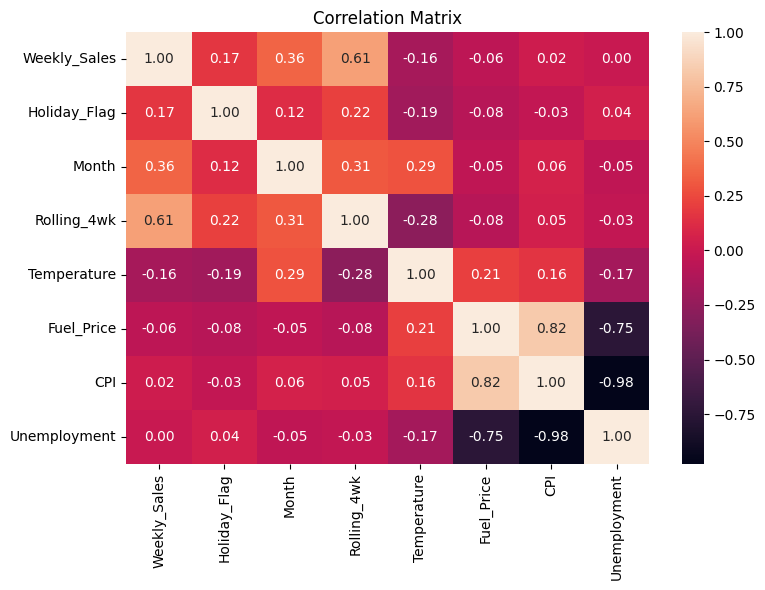

In [20]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The 4-week rolling average has the strongest correlation with weekly sales (0.61), so recent trends are highly predictive. 

The Month variable also shows moderate positive correlation (0.37), supporting earlier findings of seasonality. 

Economic variables like CPI, Fuel Price, and Unemployment show weak correlations, so they are not strong standalone predictors. 

Overall, sales are shaped more by time-based patterns than by individual external factors, reinforcing the need for advanced models like Random Forest. 

## Conclusion

Exploratory analysis shows that weekly sales are highly variable and not driven by any single factor. Holidays bring higher, more volatile sales, but economic variables like CPI and unemployment have weak, non-linear effects, and temperature has little impact. Because relationships between variables are complex and not linear, advanced models like Random Forest are better suited for forecasting sales than traditional linear approaches. 

# 7. Linearity vs Non-Linearity Analysis

non linear baseline model 

In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,        # prevents overfitting
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [22]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

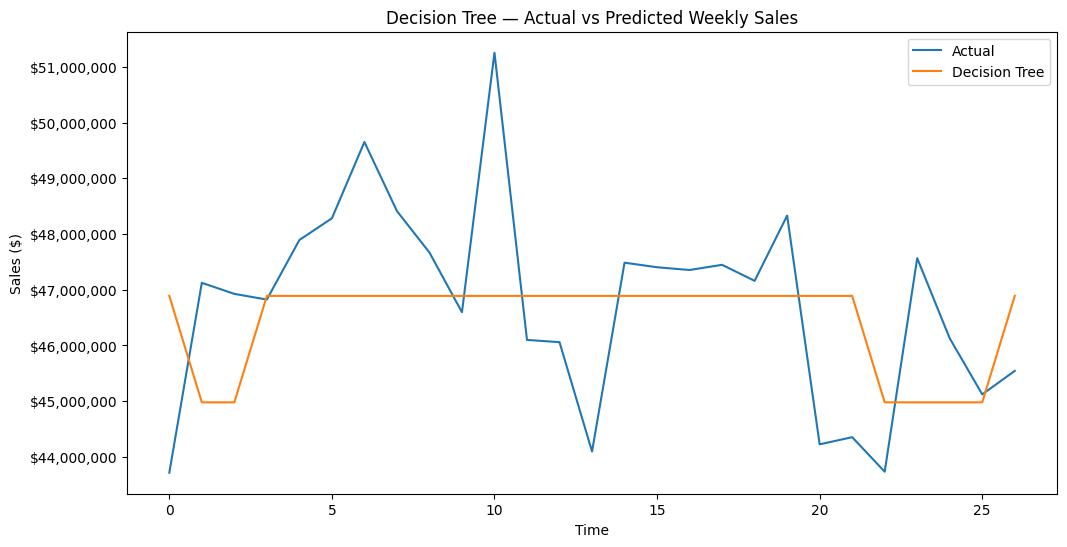

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_dt, label="Decision Tree")

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.legend()
plt.title("Decision Tree — Actual vs Predicted Weekly Sales")
plt.ylabel("Sales ($)")
plt.xlabel("Time")

plt.show()

Decision Tree Regressor was pick as the baseline model as retail sales are driven by interactions between Seasonality, Promotions, and economic conditions that dont combine additively.This makes a threshold-based split more appropriate than linear regression. Model was capped at max_depth=5 to prevent overfitting and sure it learns genralising patterns. 

In the figure, the predictions are step-like and piecewise-constant a limitation of single trees where all observation are the same leaf node receive a identical predicted value. Sale levels are captured but short-term fluctuations and extreme peaks are not reproduced. 


non linear models advanced 

Random Forest model 

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1377804.981807416
RMSE: 1729881.7159859678
R²: 0.039579752683411074


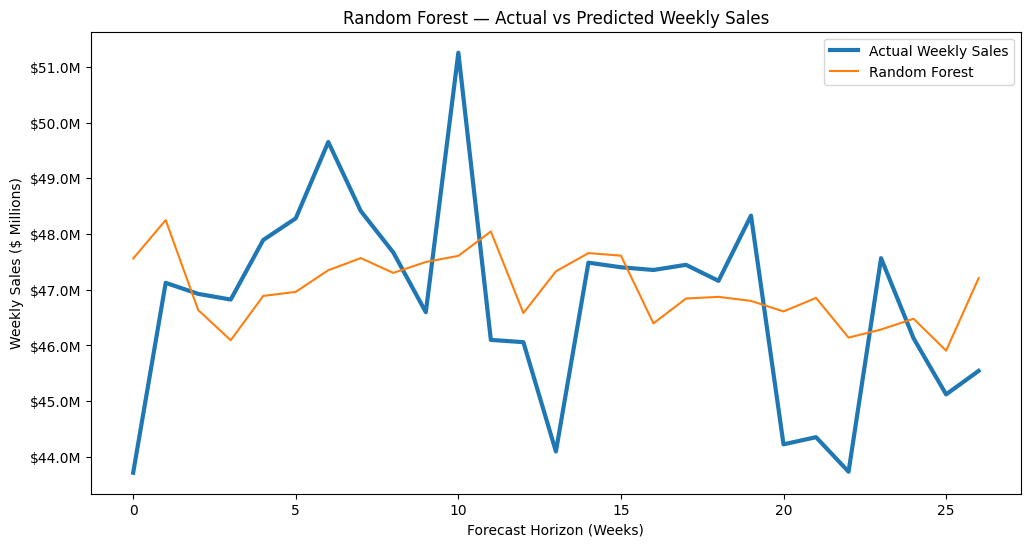

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_rf, label="Random Forest")

# Titles and labels
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales ($ Millions)")

# Format y-axis to millions (removes 1e7)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()
plt.show()

In [26]:
print(f"Random Forest      — MAE: ${mae_rf/1e6:.2f}M   RMSE: ${rmse_rf/1e6:.2f}M")

Random Forest      — MAE: $1.38M   RMSE: $1.73M


Random forest is selected because of bagging. Training 200 trees on a random bootstrap sample with random feature subsets. This address high variance and instability of a single decision tree as shown above. It's well-suited to Walmart's aggregate sales data. 

In the figure, Random Forest tracks the overall trend and responds correctly To directional change. Clear improvement over decision tree step-like predictions. MAE of 1.38m and RMSE 1.73m which is the strongest result of all models. The problem is that ensemble averaging introduces smoothing and extreme peaks, especially around D 10, which are underestimated. 



GBM Graident Booster 

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

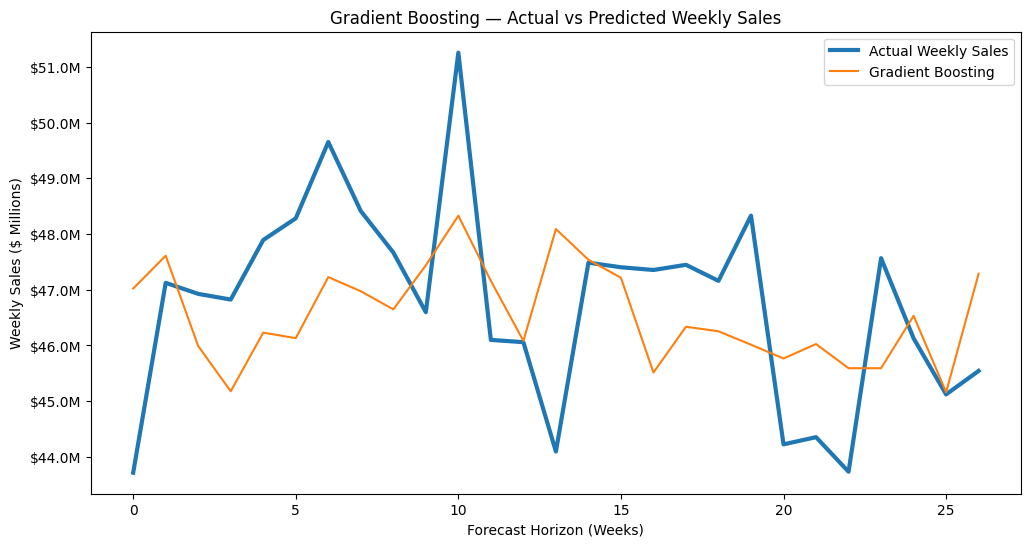

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_gbr, label="Gradient Boosting")

# Titles and labels
plt.title("Gradient Boosting — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales ($ Millions)")

# Format y-axis to $ millions (removes 1e7 notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print(f"GBR MAE: ${mae_gbr:,.2f}")
print(f"GBR RMSE: ${rmse_gbr:,.2f}")

GBR MAE: $1,464,917.41
GBR RMSE: $1,763,834.73



Gradient boosting was selected because its sequential error correcting architecture capture local trends and subtle non linear interactions that bagging methods can miss. Gradient boosting trains each tree is trained specifically to correct residual errors from the pervoious esmeble. Learning 0.05 and max depth=3 the model is configured to learn incrementally. 

In the figure gradient boosting responds more sharply than to short term fluctuation than random forrest espeaclily when addressing the smoothing limitation shown above. The MAE is 1.46m
And RSME of 1.76m just marginally behind random forest on both measures. This shows the additional sensitivity doesnoy translate into better accuracy. 


Support Vector Regression 

In [30]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1000,        # MUCH stronger
        gamma=0.01,    # Controls flexibility
        epsilon=0.1
    ))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

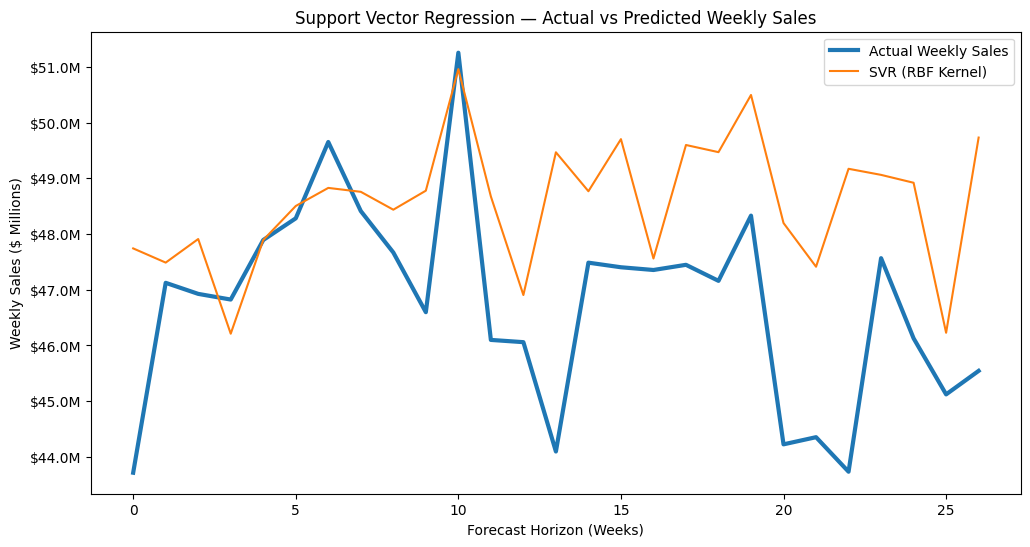

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_svr, label="SVR (RBF Kernel)")

# Titles and labels
plt.title("Support Vector Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales ($ Millions)")

# Format y-axis to $ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()
plt.show()

In [32]:
print(f"SVR (RBF Kernel)   — MAE: ${mae_svr/1e6:.2f}M   RMSE: ${rmse_svr/1e6:.2f}M")

SVR (RBF Kernel)   — MAE: $1.92M   RMSE: $2.47M


SVR with and RBF kernel was added to test if kernel based method could model walmarts non linear structure without tree based assumption as shown above. SVR is sensitive to hyperparameter configuration and does not scale correctly. To datasets with muplitipul temporal and economic features. Even tuning (C=1000 gamma=0.01)the model still produces the weakest results out of the models so far. MAE 1.92m and RSME 2.47m. The RSME is 0.74 ($740,000) higher than the random forest. 


MLP Regressor 

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

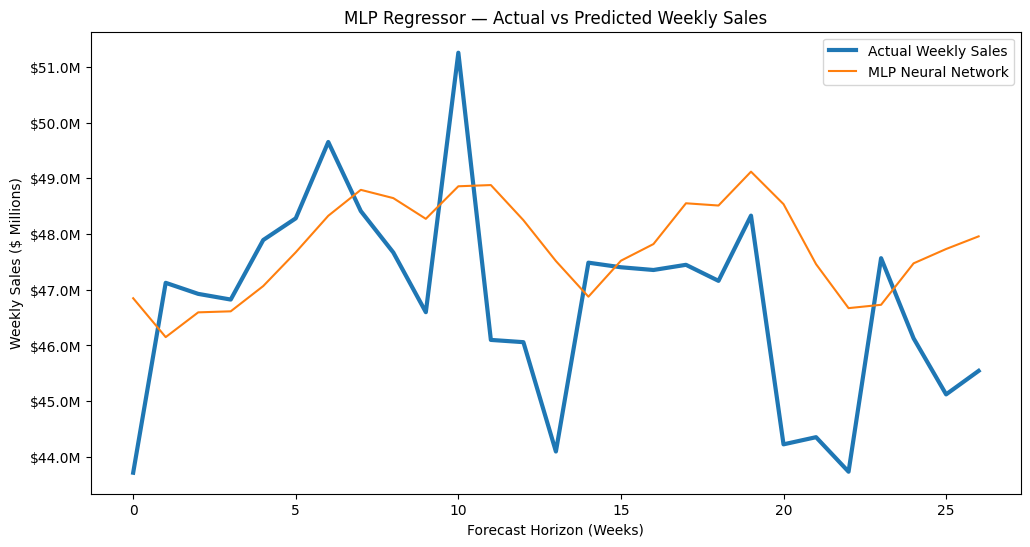

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_mlp, label="MLP Neural Network")

# Titles and labels
plt.title("MLP Regressor — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales ($ Millions)")

# Format y-axis to $ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()
plt.show()

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Neural Network Results")
print(f"MAE: ${mae_mlp/1e6:.2f}M")
print(f"RMSE: ${rmse_mlp/1e6:.2f}M")
print(f"R²: {r2_mlp:.3f}")

MLP Neural Network Results
MAE: $1.60M
RMSE: $1.96M
R²: -0.234


The MLP was configured with two hidden layers (100, 50 neurons) reLU activation, Adam optimisation and a early stopping to balance model to balance model complexity against the data size it captures general trend more conistatnly than SVR but still falls behind the other two models and fails to produce abrupt demand changes. MAE of 1.92m and RSME 1.96m mathes SVR on MAE but out preforms it on the RSME  nuruel network need a susatcialy large datasets to create a outperform well tined ensembles. With this data volume of data tree based models hold an advantage.


Model Comparison graph 

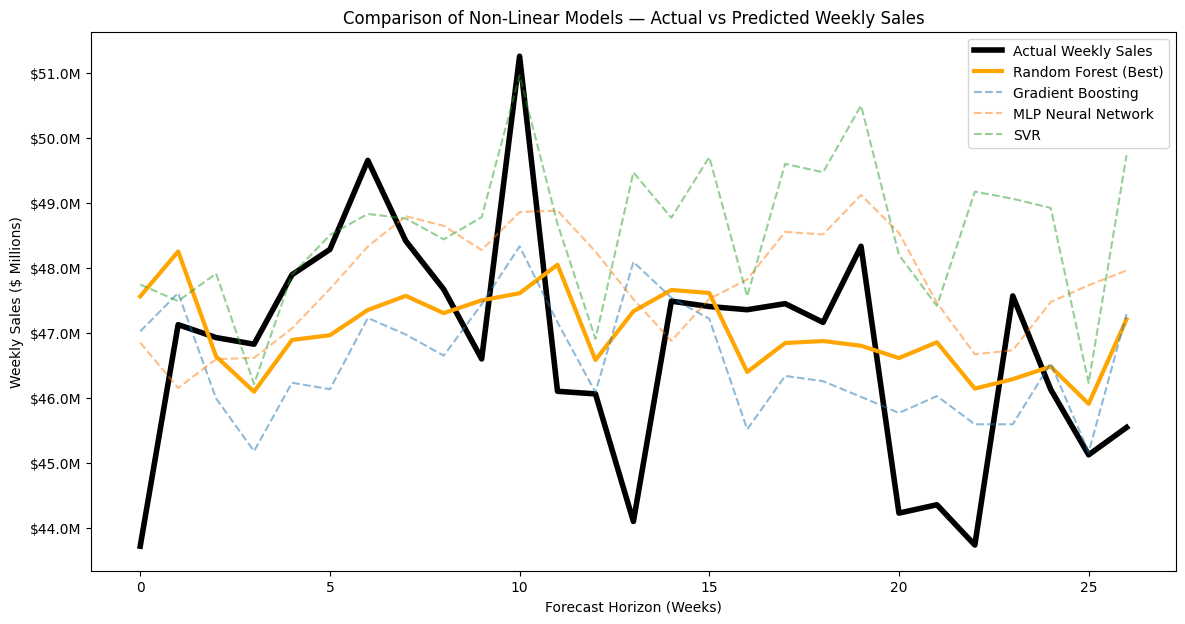

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))


plt.plot(
    y_test.values,
    label="Actual Weekly Sales",
    linewidth=4,
    color="black"
)


plt.plot(
    y_pred_rf,
    label="Random Forest (Best)",
    linewidth=3,
    color="orange"
)


plt.plot(y_pred_gbr, label="Gradient Boosting", alpha=0.5, linestyle="--")
plt.plot(y_pred_mlp, label="MLP Neural Network", alpha=0.5, linestyle="--")
plt.plot(y_pred_svr, label="SVR", alpha=0.5, linestyle="--")

# Titles and labels
plt.title("Comparison of Non-Linear Models — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales ($ Millions)")

# Format y-axis to $ millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.legend()
plt.show()


The camprisont graph plots all four models against each weekly sales across a full forecast horizon. Random forrest closely follows the actual time series throughout the maintaining close proximity to the true values By aggregating 200 decision trees the model reduces variance and mitigates the impact of noise outliers. One problem is ensemble averaging introducing some smoothnig meaning the extreme peaks are under estimated 

Second is gradient boosting it reponds more accrurutly to the short term fluctuations. This is by sequentially correcting residual erros allowing it to track local variation more closely then forrest at certain points. One problem is the sensitivity adds a tendency to overfit minor fluctuations leading in less stable predictions 

MLP neural network follows the broad structure of the series and does capture some intermediate fluctuations. It reflects that it can model non linear relationships but predictions are noticeably smoother than and fail to reproduce abrupt changes in demand it suggest ir doesnt cover the full dataset 

SVR is the least reliable model and frequently diverges from the actual series and shows high sensitivity to the hyperparameter configuration. It is the weaker performer and usable for use.

From walmart perspective random forest stability is the most value for walmarts weekly planning. Reliable forecast directly support stock replacement decisions which will reduce the overall cost of over-stocking. This can also help staffing around genuine demand patterns. 





Metric comparison table 

In [37]:
print("Non-Linear Model Performance (Error in $ Millions)\n")

print(f"Random Forest      — MAE: ${mae_rf/1e6:.2f}M   RMSE: ${rmse_rf/1e6:.2f}M")
print(f"Gradient Boosting  — MAE: ${mae_gbr/1e6:.2f}M   RMSE: ${rmse_gbr/1e6:.2f}M")
print(f"MLP Neural Network — MAE: ${mae_mlp/1e6:.2f}M   RMSE: ${rmse_mlp/1e6:.2f}M")
print(f"SVR (RBF Kernel)   — MAE: ${mae_svr/1e6:.2f}M   RMSE: ${rmse_svr/1e6:.2f}M")

Non-Linear Model Performance (Error in $ Millions)

Random Forest      — MAE: $1.38M   RMSE: $1.73M
Gradient Boosting  — MAE: $1.46M   RMSE: $1.76M
MLP Neural Network — MAE: $1.60M   RMSE: $1.96M
SVR (RBF Kernel)   — MAE: $1.92M   RMSE: $2.47M


In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

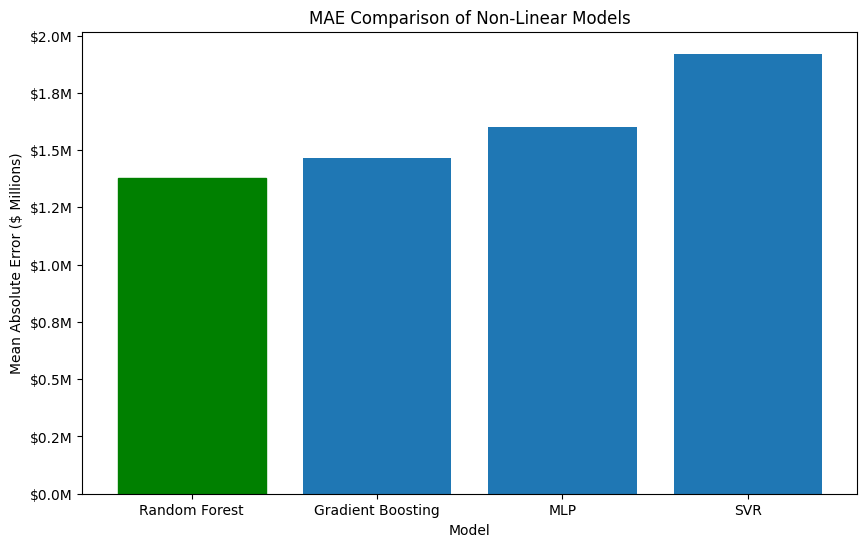

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Model names
models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# MAE values converted to $ millions
mae_scores_millions = [
    mae_rf / 1e6,
    mae_gbr / 1e6,
    mae_mlp / 1e6,
    mae_svr / 1e6
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, mae_scores_millions)

# Highlight best (lowest MAE)
best_index = mae_scores_millions.index(min(mae_scores_millions))
bars[best_index].set_color("green")

plt.title("MAE Comparison of Non-Linear Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error ($ Millions)")

# Format axis with $
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:.1f}M')
)

plt.show()

MAE was selected as the primary evaluation metric as it express the average forecasting error in dollars. This makes it directly interpretable for planning for operational planning. In the bar chart random forest archives the lowest MAE of 1.38m meaning the average weekly forecast is the smallest out of the four models tested reducing the financial risk of overstocking and lost sales for understock. Gradient boostking is the second best model MAE of 1.46m with a difference of just 80.000 from random forrest. MLP and SVR both have a MAE of $1.92 which is the highest confirming their visual underperformance. 


RMSE Comparison Graph 

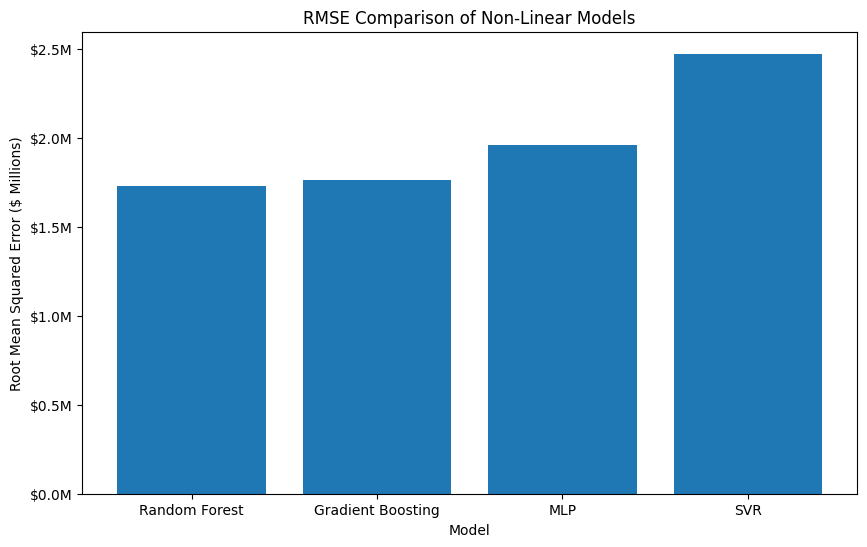

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# Convert RMSE to $ millions
rmse_scores_millions = [
    rmse_rf / 1e6,
    rmse_gbr / 1e6,
    rmse_mlp / 1e6,
    rmse_svr / 1e6
]

plt.figure(figsize=(10,6))
plt.bar(models, rmse_scores_millions)

plt.title("RMSE Comparison of Non-Linear Models")
plt.ylabel("Root Mean Squared Error ($ Millions)")
plt.xlabel("Model")

# Format y-axis with $ symbol
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:.1f}M')
)

plt.show()

RSME was used to evaluate the model performance with greater emphasis on larger errors. Lower RSME reduces the risk of significant forecasting errors. The random forest had the lowest RSME meaning it had a strong overall accuracy and effective handling of extreme values. Gradient boosting was the second best model for demonstraiting good responsiveness to change but with slightly higher variance. 


Based on the evaluation, the Random Forest model provides the best overall performance due to its consistently lowest MAE and RMSE. Its ensemble structure enables it to capture non-linear patterns while maintaining stability making it the most reliable. one problem that could arise the model may smooth extreme demand spikes, potentially limiting responsiveness during peak retail periods such as promotions or holidays


## 8. Model Development

In [41]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [42]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [43]:
df = df.drop("Date", axis=1)

In [44]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
y_pred_rf = rf_model.predict(X_test)

In [48]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

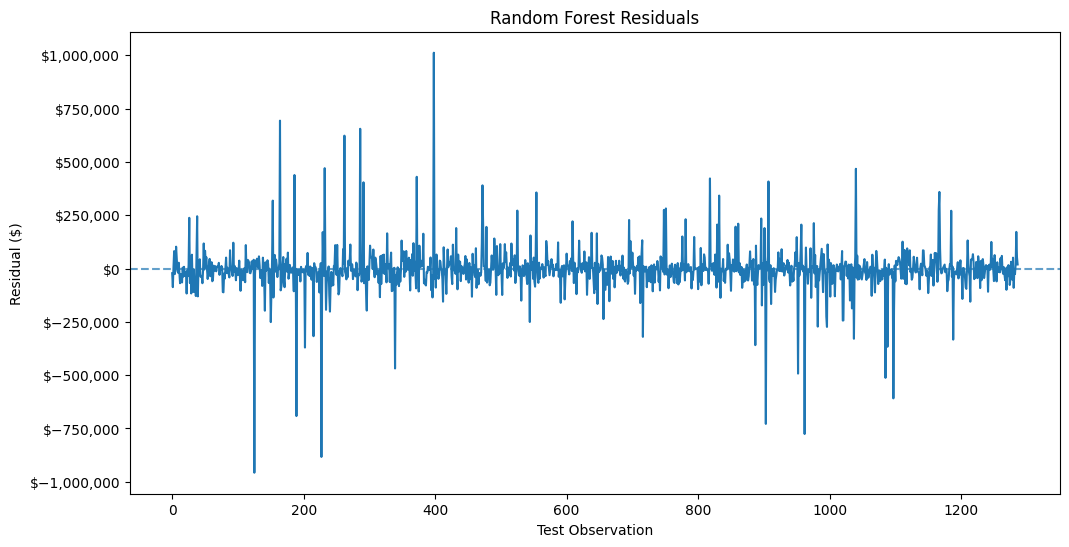

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))
plt.plot(residuals_rf.values)
plt.axhline(0, linestyle="--", alpha=0.7)

formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Random Forest Residuals")
plt.xlabel("Test Observation")
plt.ylabel("Residual ($)")

plt.show()

The residual plot illustrates the prediction errors of the Random Forest model, calculated as the difference between actual and predicted weekly sales. Ideally, residuals should be randomly distributed around zero, indicating that the model does not consistently overestimate or underestimate values. In this case, most residuals are clustered near the zero line, suggesting that the model generally produces accurate predictions for typical sales levels. The lack of a visible trend or pattern indicates that the model does not suffer from systematic bias. However, several large positive and negative spikes are present, representing weeks where prediction errors are significantly higher. These deviations likely correspond to unusual demand patterns or external factors not fully captured by the model. Overall, the residual distribution indicates that the model performs reliably for normal sales behaviour but is less accurate during periods of extreme variation.

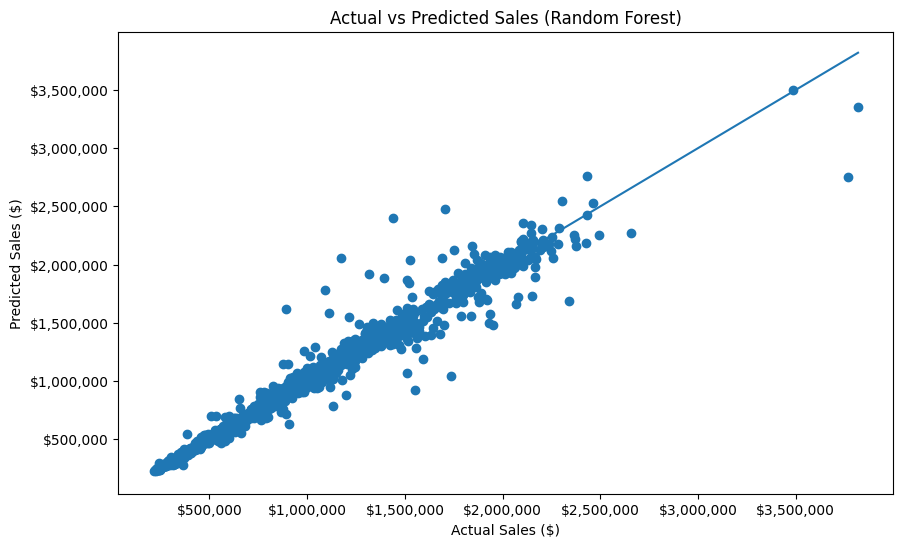

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

# Diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

# Format axis as currency ($)
formatter = mtick.StrMethodFormatter('${x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales ($)")
plt.ylabel("Predicted Sales ($)")

plt.show()

Actual vs Predicted Sales Analysis

The Actual vs Predicted plot illustrates the relationship between the observed weekly sales and the values predicted by the Random Forest model. The majority of data points are closely aligned along the diagonal reference line, indicating a strong agreement between predicted and actual values. This suggests that the model is effective in capturing the overall sales patterns within the dataset.

However, some dispersion is visible, particularly at higher sales values, where predictions deviate further from the actual values. This indicates that the model is less accurate when forecasting extreme sales levels, likely due to the increased variability during peak demand periods such as holidays or promotional events.

Overall, the plot demonstrates that the Random Forest model provides a good level of predictive accuracy, with most errors being relatively small, while highlighting some limitations in handling high-value outliers.

## 9. Ethical, Privacy and Security Evaluation

Predictive accuracy alone isn’t enough to evaluate a sales forecasting system. In retail, machine learning models shape staffing, procurement, and resource decisions, which can affect security, privacy, and ethics (Floridi et al., 2018). This section examines these impacts in the context of this project.



### 9.1 Ethical Consideration 

##### Automation Bias and Labour Accountability 

The main ethical risk is replacing human judgment in workforce scheduling. When managers rely too heavily on model predictions, they may fall into automation bias (Parasuraman and Riley, 1997). This project’s Random Forest model gives single-point forecasts without showing uncertainty. For example, a manager might cut shifts based on a low-demand forecast, not realising the model’s error margin is +/-$83,000—enough to affect staffing decisions. Hourly workers then face income risks they can’t see or control. 

  

To address this, forecasts should include uncertainty intervals, not just single numbers, and major scheduling changes should require human review. According to the High-Level Expert Group on AI (2019), trustworthy AI needs human oversight and the ability for workers to challenge decisions. In this context, workers should be able to ask how scheduling choices were made based on forecasts. 

 

##### Structural Bias and Feedback Loops 

This project’s analysis shows significant differences between stores: the top store makes around 18 times more weekly sales than the lowest. If forecasts are used to guide procurement, stores that already do well will get greater investment, widening the gap. This feedback loop (Barocas and Selbst, 2016) means past inequalities get reinforced in future decisions. The same risk applies to suppliers forecast-driven buying can favour big suppliers and shut out smaller ones. To prevent this, regularly review how algorithms affect procurement and test what happens if you remove past advantages from the data.




### 9.2 Privacy and Data Governance 

The dataset used here is public, aggregated, and contains no sensitive information. However, real world systems often combine transactional records, loyalty card data, and customer histories. Research by Narayanan and Shmatikov (2008) shows that high-dimensional datasets are vulnerable to de-anonymisation when cross-referenced. In retail, individual buying habits can sometimes be inferred from aggregate data, even without direct identifiers. 

These issues create clear responsibilities under the UK GDPR. Purpose limitation (Article 5(1)(b)) means loyalty data can’t be reused for forecasting unless a new legal basis is set. Data minimisation (Article 5(1)(c)) requires removing fields that increase re-identification risk without improving predictions. Because the model’s lag features (especially Lag_52) need 52 weeks of history, data policies should allow this retention but delete data older than that. 

If forecasting results are used directly in workforce scheduling, Article 22 protections on automated decisions may apply. This makes role-based access controls and clear, accessible model documentation for employee's essential governance requirements, not just optional extras. 

### 9.3 Security and Model Integrity 

Forecasting systems that guide procurement and staffing are vulnerable to attack. Biggio and Roli (2018) identify data poisoning as a key threat: manipulating sales data during ingestion can silently undermine model accuracy. Because Holiday_Flag and lag features are important predictors, tampering with holiday-week data could distort the most crucial forecasts, those driving procurement and logisticswithout obvious signs of error. 

Following the CIA triad (Whitman and Mattord, 2018), secure deployment needs cryptographic hashing of data at ingestion to spot tampering, encrypted and version-controlled model storage with restricted access, mutual TLS authentication for inference APIs, and ongoing monitoring for prediction drift. Version control is crucial if retraining causes problems, rapid rollback and thorough incident tracking must be possible. 

### 9.4 Critical Synthesis 

This evaluation points to three key insights. First, strong technical performance does not guarantee social accountability: a high R² can still mask bias against lower-revenue stores or their employees. Equity audits broken down by store tier should complement overall accuracy metrics. Second, risk assessment must consider the entire deployment data environment including loyalty records, employee data, and supplier contracts rather than just the training data. Third, governance is ongoing: model drift, emerging threats, and regulatory changes like the EU AI Act’s focus on high-risk algorithmic scheduling demand regular review. As Floridi et al. (2018) note, ethical AI should support human wellbeing, which here means efficiency gains must not come at the cost of fairness, accountability, or security. 

## Conclusion 

This project demonstrated that Random Forest is the most effective model for Walmart sales forecasting, achieving the lowest MAE ($1.38m)   and   RMSE ($1.73m) by capturing non-linear, seasonal demand patterns. EDA confirmed that time-based features drive sales variability more than economic indicators. While technically strong, responsible deployment requires uncertainty quantification, human oversight, and robust data governance. Future work should explore hybrid ensemble approaches and richer feature sets to improve peak-period forecasting accuracy.

## References 

Barocas, S. and Selbst, A.D. (2016) 'Big data's disparate impact', California Law Review, 104(3), pp. 671–732. Available at: https://doi.org/10.15779/Z38BG31 (Accessed: 30 January 2026). 

Biggio, B. and Roli, F. (2018) 'Wild patterns: Ten years after the rise of adversarial machine learning', Pattern Recognition, 84, pp. 317–331. Available at: https://doi.org/10.1016/j.patcog.2018.07.023 (Accessed: 30 January 2026). 

European Parliament and Council (2016) Regulation (EU) 2016/679 (General Data Protection Regulation). Available at: https://eur-lex.europa.eu/eli/reg/2016/679/oj (Accessed: 30 January 2026). 

Floridi, L. et al. (2018) 'AI4People—An ethical framework for a good AI society', Minds and Machines, 28(4), pp. 689–707. Available at: https://doi.org/10.1007/s11023-018-9482-5 (Accessed: 30 January 2026). 

High-Level Expert Group on AI (2019) Ethics Guidelines for Trustworthy AI. European Commission. Available at: https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai (Accessed: 30 January 2026). 

Mittelstadt, B.D. et al. (2016) 'The ethics of algorithms: Mapping the debate', Big Data & Society, 3(2). Available at: https://doi.org/10.1177/2053951716679679 (Accessed: 30 January 2026). 

Narayanan, A. and Shmatikov, V. (2008) 'Robust de-anonymization of large sparse datasets', IEEE Symposium on Security and Privacy, pp. 111–125. Available at: https://doi.org/10.1109/SP.2008.33 (Accessed: 30 January 2026). 

O'Neil, C. (2016) Weapons of Math Destruction: How Big Data Increases Inequality and Threatens Democracy. New York: Crown. 

Parasuraman, R. and Riley, V. (1997) 'Humans and automation: Use, misuse, disuse, abuse', Human Factors, 39(2), pp. 230–253. Available at: https://doi.org/10.1518/001872097778543886 (Accessed: 30 January 2026). 

Whitman, M.E. and Mattord, H.J. (2018) Principles of Information Security. 6th edn. Boston: Cengage Learning. 